# Tema 1. Introducción al aprendizaje automático

##     1.2. Supervisado vs. no supervisado

In [2]:
import seaborn as sns
import pandas as pd

# Cargar el dataset del Titanic
df = sns.load_dataset('titanic')

# Mostrar algunas columnas clave
df[['age', 'sex', 'pclass', 'fare', 'survived']].head()



,age,sex,pclass,fare,survived
0,22.0,male,3,7.2500,0
1,38.0,female,1,71.2833,1
2,26.0,female,3,7.9250,1
3,35.0,female,1,53.1000,1
4,35.0,male,3,8.0500,0


## 1.3 Regresión vs Clasificación


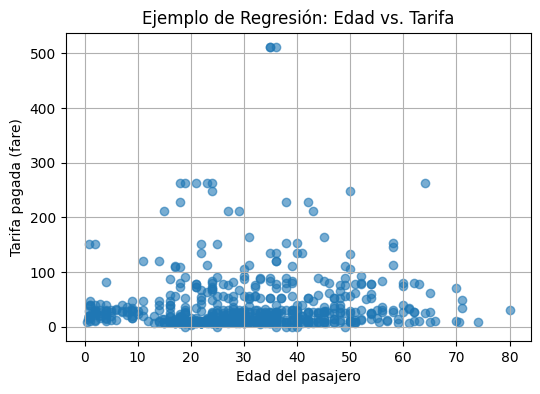

In [3]:
# Código y figura 1

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y limpiar el dataset
df = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])

# Visualizar relación entre edad y tarifa pagada
plt.figure(figsize=(6, 4))
plt.scatter(df['age'], df['fare'], alpha=0.6)
plt.title('Ejemplo de Regresión: Edad vs. Tarifa')
plt.xlabel('Edad del pasajero')
plt.ylabel('Tarifa pagada (fare)')
plt.grid(True)
plt.show()


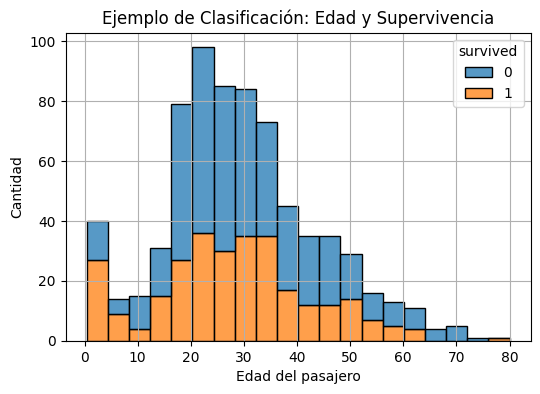

In [4]:
# Código y figura 2

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y limpiar el dataset
df = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])

# Histograma con variable categórica `survived`
plt.figure(figsize=(6, 4))
sns.histplot(df, x='age', hue='survived', multiple='stack', bins=20)
plt.title('Ejemplo de Clasificación: Edad y Supervivencia')
plt.xlabel('Edad del pasajero')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()


## Subtema 1.4 – Valores continuos

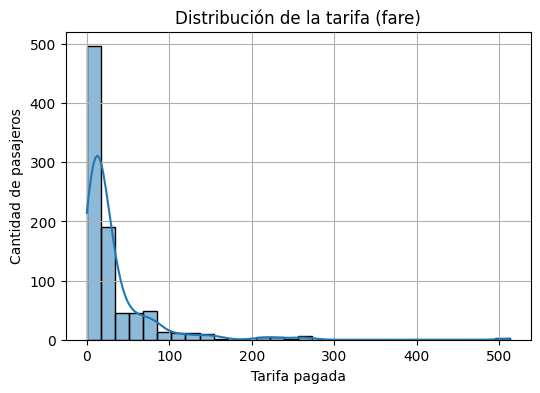

In [5]:
#Figura 4. Visualización de variables continuas.
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset('titanic')

# Visualizar la distribución de la tarifa pagada
plt.figure(figsize=(6, 4))
sns.histplot(df['fare'].dropna(), bins=30, kde=True)
plt.title('Distribución de la tarifa (fare)')
plt.xlabel('Tarifa pagada')
plt.ylabel('Cantidad de pasajeros')
plt.grid(True)
plt.show()


## Subtema 1.5 – Categorías o clases; valores discretos

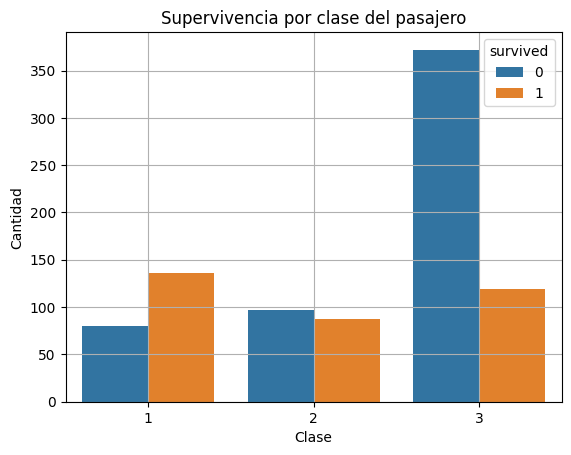

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar datos
df = sns.load_dataset('titanic')

# Clasificar por clase del pasajero
sns.countplot(data=df, x='pclass', hue='survived')
plt.title('Supervivencia por clase del pasajero')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.grid(True)
plt.show()


# Tema 2. Métricas de evaluación en modelos de aprendizaje automático

## 2.1 Métricas de evaluación

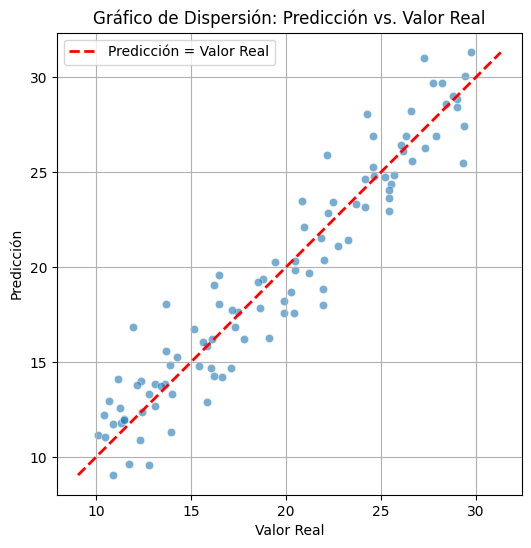

In [7]:
# Gráfica de dispersión simple que muestre predicción vs. valor real para regresión (línea ideal + puntos), para introducir el concepto de “ajuste al valor real”.

import numpy as np

# Simular datos de predicción y valor real
np.random.seed(42)
n_samples = 100
real_values = 10 + 2 * np.random.rand(n_samples) * 10
predictions = real_values + np.random.randn(n_samples) * 2

# Crear DataFrame
df_eval = pd.DataFrame({'Valor Real': real_values, 'Predicción': predictions})

# Crear gráfico de dispersión
plt.figure(figsize=(6, 6))
sns.scatterplot(x='Valor Real', y='Predicción', data=df_eval, alpha=0.6)

# Añadir línea ideal (predicción = valor real)
min_val = min(df_eval['Valor Real'].min(), df_eval['Predicción'].min())
max_val = max(df_eval['Valor Real'].max(), df_eval['Predicción'].max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', lw=2, label='Predicción = Valor Real')

plt.title('Gráfico de Dispersión: Predicción vs. Valor Real')
plt.xlabel('Valor Real')
plt.ylabel('Predicción')
plt.legend()
plt.grid(True)
plt.axis('equal') # Asegura que los ejes tengan la misma escala
plt.show()

## Subtema 2.2 – R², R² ajustado, MAE y puntuación F1

In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import seaborn as sns

df = sns.load_dataset('titanic').dropna(subset=['age', 'fare'])
X = df[['age']]; y = df['fare']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))


R²: 0.001369139534141195
MAE: 29.213315658761626


# Tema 3. Aplicación en Python de la regresión lineal y de la regresión logística

## 3.1. Regresión lineal simple

In [1]:
# Paso 1: Carga de librerías y datos
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Dataset Titanic
df = sns.load_dataset('titanic')

# Eliminamos valores nulos
df = df[['age', 'fare']].dropna()


In [3]:
#Paso 2. Definición de variables

X = df['age']      # Variable independiente
y = df['fare']     # Variable dependiente

# Agregamos constante para el modelo (intercepto)
X_const = sm.add_constant(X)


In [4]:
# Paso 3. Construcción y resumen del modelo
modelo = sm.OLS(y, X_const).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     6.632
Date:                Wed, 30 Jul 2025   Prob (F-statistic):             0.0102
Time:                        19:23:54   Log-Likelihood:                -3843.0
No. Observations:                 714   AIC:                             7690.
Df Residuals:                     712   BIC:                             7699.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         24.3009      4.492      5.410      0.0

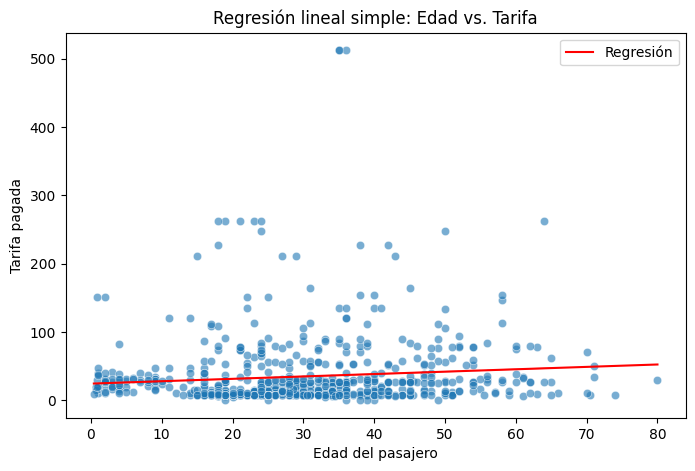

In [5]:
## Paso 4. Visualización del modelo:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='fare', data=df, alpha=0.6)
sns.lineplot(x=df['age'], y=modelo.predict(X_const), color='red', label='Regresión')
plt.title('Regresión lineal simple: Edad vs. Tarifa')
plt.xlabel('Edad del pasajero')
plt.ylabel('Tarifa pagada')
plt.legend()
plt.show()


## 3.2 Regresión lineal múltiple

In [21]:
#Paso 1. Preparar los datos

#Importar las librerías necesarias
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
# Cargar el dataset Titanic desde seaborn
df = sns.load_dataset('titanic')
# Seleccionar variables de interés
df = df[['fare', 'age', 'pclass', 'sex', 'embarked']]

# Eliminar filas con valores faltantes
df = df.dropna()

# Mostramos los tipos de datos por columna
print("Tipos de datos por columna:")
print(df.dtypes)


Tipos de datos por columna:
fare        float64
age         float64
pclass        int64
sex          object
embarked     object
dtype: object


In [22]:
#Paso 2. Codificar las variables categóricas

# Codificación de variables categóricas
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

# Mostramos una vez más el resultado de las columnas resultantes

print("Tipos de datos por columna:")
print(df.dtypes)


Tipos de datos por columna:
fare          float64
age           float64
pclass          int64
sex_male         bool
embarked_Q       bool
embarked_S       bool
dtype: object


In [23]:
# Paso 3: Codificar las variables boleanas resultantes.

# Convertir columnas booleanas a enteros (0 o 1)
for col in df.select_dtypes(include='bool').columns:
    df[col] = df[col].astype(int)

print("Tipos de datos por columna:")
print(df.dtypes)


Tipos de datos por columna:
fare          float64
age           float64
pclass          int64
sex_male        int64
embarked_Q      int64
embarked_S      int64
dtype: object


In [24]:
# Paso 4. Definir variables predictoras y objetivo

# Variable dependiente
y = df['fare']

# Variables independientes
X = df.drop(columns='fare')

# Agregar constante para el modelo
X_const = sm.add_constant(X)

print("Tipos de X:")
print(X_const.dtypes)

print("Tipo de y:", y.dtypes)


Tipos de X:
const         float64
age           float64
pclass          int64
sex_male        int64
embarked_Q      int64
embarked_S      int64
dtype: object
Tipo de y: float64


In [25]:
# Paso 5. Ajustar el modelo de regresión lineal múltiple

modelo = sm.OLS(y, X_const).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                   fare   R-squared:                       0.346
Model:                            OLS   Adj. R-squared:                  0.342
Method:                 Least Squares   F-statistic:                     74.81
Date:                Wed, 30 Jul 2025   Prob (F-statistic):           6.89e-63
Time:                        23:32:10   Log-Likelihood:                -3684.5
No. Observations:                 712   AIC:                             7381.
Df Residuals:                     706   BIC:                             7408.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        143.8423      7.267     19.795      0.0

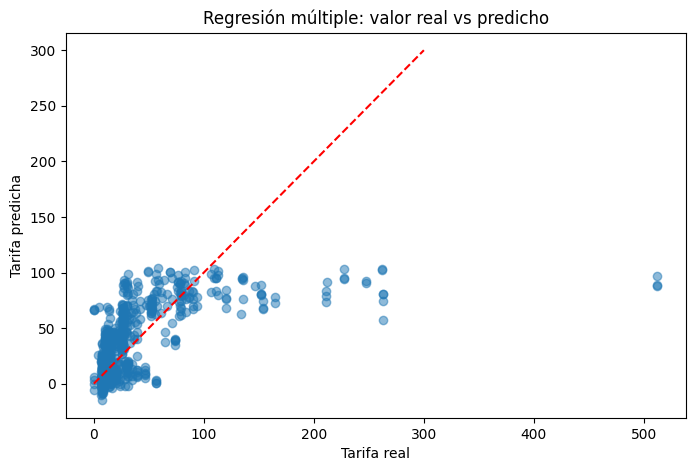

In [26]:
# Paso 6. Visualizar el ajuste del modelo.

# Agregar predicciones al DataFrame
df['predicted_fare'] = modelo.predict(X_const)

# Gráfica real vs. predicho
plt.figure(figsize=(8,5))
plt.scatter(df['fare'], df['predicted_fare'], alpha=0.5)
plt.plot([0, 300], [0, 300], 'r--')
plt.xlabel('Tarifa real')
plt.ylabel('Tarifa predicha')
plt.title('Regresión múltiple: valor real vs predicho')
plt.show()


## Subtema 3.3 – Regresión logística binaria

In [27]:
# Paso 1: Preparar los datos

import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Cargar dataset
df = sns.load_dataset('titanic')

# Selección de variables
df = df[['survived', 'sex', 'pclass', 'age']]

# Eliminación de valores nulos
df = df.dropna()


In [28]:
# Paso 2: Codificación profesional de variables
# Crear variables dummy
df = pd.get_dummies(df, columns=['sex'], drop_first=True)

# Convertir columnas booleanas a enteros
for col in df.select_dtypes(include='bool'):
    df[col] = df[col].astype(int)



In [29]:
# Paso 3: Definir variable objetivo y predictoras
# Variable objetivo
y = df['survived']

# Variables predictoras
X = df[['age', 'pclass', 'sex_male']]

# Agregar constante
X_const = sm.add_constant(X)


In [30]:
# Paso 4: Entrenar modelo de regresión logística
# Entrenamiento del modelo logístico
modelo = sm.Logit(y, X_const).fit()

# Resumen del modelo
print(modelo.summary())


Optimization terminated successfully.
         Current function value: 0.453285
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               survived   No. Observations:                  714
Model:                          Logit   Df Residuals:                      710
Method:                           MLE   Df Model:                            3
Date:                Thu, 31 Jul 2025   Pseudo R-squ.:                  0.3289
Time:                        00:09:47   Log-Likelihood:                -323.65
converged:                       True   LL-Null:                       -482.26
Covariance Type:            nonrobust   LLR p-value:                 1.860e-68
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0560      0.502     10.069      0.000       4.072       6.040
age           -0.0369      0.

In [31]:
# Paso 5: Evaluar el modelo
from sklearn.metrics import confusion_matrix, classification_report

# Probabilidades predichas
df['pred_prob'] = modelo.predict(X_const)

# Clasificación usando umbral de 0.5
df['predicted'] = (df['pred_prob'] >= 0.5).astype(int)

# Evaluación
print(confusion_matrix(df['survived'], df['predicted']))
print(classification_report(df['survived'], df['predicted']))


[[356  68]
 [ 83 207]]
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       424
           1       0.75      0.71      0.73       290

    accuracy                           0.79       714
   macro avg       0.78      0.78      0.78       714
weighted avg       0.79      0.79      0.79       714



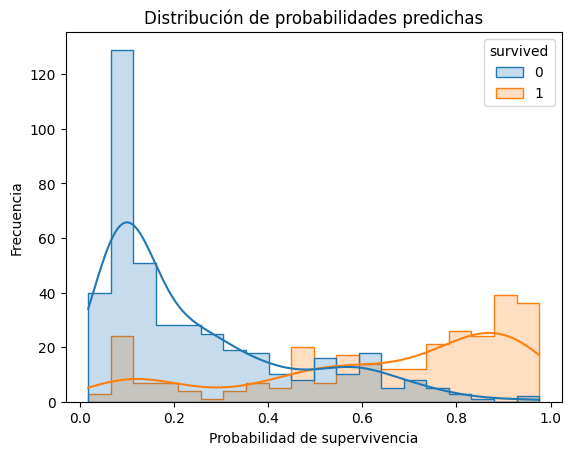

In [32]:
# Paso 6: Visualización de las predicciones
# Distribución de probabilidades predichas
import seaborn as sns

sns.histplot(data=df, x='pred_prob', hue='survived', bins=20, kde=True, element='step')
plt.title("Distribución de probabilidades predichas")
plt.xlabel("Probabilidad de supervivencia")
plt.ylabel("Frecuencia")
plt.show()


In [37]:

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Cargar y limpiar el dataset
df = sns.load_dataset('titanic')


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


## Subtema 3.4 – Regresión logística multinomial

In [1]:
# Paso 1: Preparar los datos
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')
df = df[['pclass', 'age', 'fare', 'sex']].dropna()


In [2]:
#Paso 2: Codificación profesional (dummy + conversión boolean→int)

df = pd.get_dummies(df, columns=['sex'], drop_first=True)
for col in df.select_dtypes(include='bool'):
    df[col] = df[col].astype(int)


In [3]:
# Paso 3: Variables predictoras y objetivo
X = df[['age', 'fare', 'sex_male']]
y = df['pclass']


In [7]:
# Paso 4: Dividir datos y entrenar el modelo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.3, random_state=42)

modelo = LogisticRegression(solver='lbfgs', max_iter=200)
modelo.fit(X_train, y_train)


LogisticRegression(max_iter=200)

In [8]:
# Paso 5: Evaluación del modelo
from sklearn.metrics import classification_report, confusion_matrix

y_pred = modelo.predict(X_test)
matriz = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred, labels=[1, 2, 3]))


              precision    recall  f1-score   support

           1       0.86      0.91      0.89        56
           2       0.68      0.29      0.41        52
           3       0.75      0.94      0.84       107

    accuracy                           0.78       215
   macro avg       0.77      0.71      0.71       215
weighted avg       0.77      0.78      0.75       215



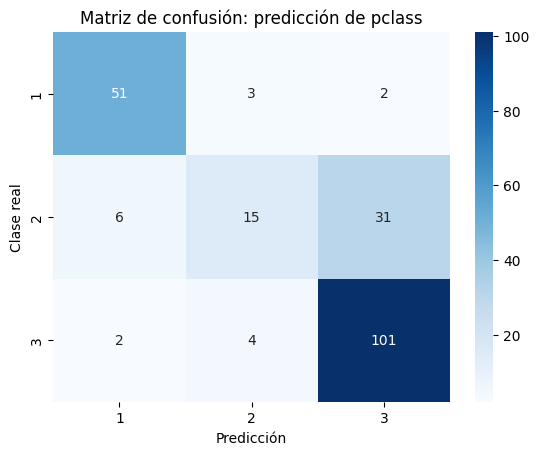

In [9]:
# Paso 6: Visualización de la matriz de confusión
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1, 2, 3], yticklabels=[1, 2, 3])
plt.xlabel('Predicción')
plt.ylabel('Clase real')
plt.title('Matriz de confusión: predicción de pclass')
plt.show()


## 3.5 Regresión logística ordinal

In [10]:
#Paso 1: Cargar y preparar los datos
import pandas as pd
import seaborn as sns

df = sns.load_dataset('titanic')
df = df[['pclass', 'age', 'fare', 'sex']].dropna()
df['sex_male'] = (df['sex'] == 'male').astype(int)


In [11]:
#Paso 2: Definir X e y
X = df[['age', 'fare', 'sex_male']]
y = df['pclass']  # Valor ordinal: 1, 2, 3


In [12]:
# Paso 3: Ajustar modelo ordinal
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

model = OrderedModel(y, X, distr='logit')
result = model.fit(method='bfgs')


Optimization terminated successfully.
         Current function value: 0.606676
         Iterations: 25
         Function evaluations: 28
         Gradient evaluations: 28


In [13]:
# Paso 4: Ver resultados
print(result.summary())

                             OrderedModel Results                             
Dep. Variable:                 pclass   Log-Likelihood:                -433.17
Model:                   OrderedModel   AIC:                             876.3
Method:            Maximum Likelihood   BIC:                             899.2
Date:                Fri, 01 Aug 2025                                         
Time:                        02:39:27                                         
No. Observations:                 714                                         
Df Residuals:                     709                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
age           -0.0642      0.007     -9.542      0.000      -0.077      -0.051
fare          -0.1031      0.008    -13.679      0.0

## 3.6 Métricas de evaluación en el modelo de regresión lineal y regresión logística


In [16]:
# Parte 1: Evaluación del modelo de regresión lineal múltiple

# Preparación previa
import seaborn as sns
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = sns.load_dataset('titanic')
df = df[['fare', 'age', 'pclass', 'sex', 'embarked']].dropna()
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)
for col in df.select_dtypes(include='bool'):
    df[col] = df[col].astype(int)

# Variable dependiente y predictoras
y = df['fare']
X = df.drop(columns='fare')

# División y entrenamiento con statsmodels
import statsmodels.api as sm
X_const = sm.add_constant(X)
modelo_rl = sm.OLS(y, X_const).fit()
y_pred_rl = modelo_rl.predict(X_const)

# Métricas de regresión
mae = mean_absolute_error(y, y_pred_rl)
mse = mean_squared_error(y, y_pred_rl)
r2 = r2_score(y, y_pred_rl)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 22.81
MSE: 1829.38
R²: 0.35


In [17]:
# Parte 2: Evaluación del modelo de regresión logística binaria

# Preparación
df = sns.load_dataset('titanic')
df = df[['survived', 'age', 'pclass', 'sex']].dropna()
df = pd.get_dummies(df, columns=['sex'], drop_first=True)
for col in df.select_dtypes(include='bool'):
    df[col] = df[col].astype(int)

y = df['survived']
X = df.drop(columns='survived')

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42)
modelo_log = LogisticRegression()
modelo_log.fit(X_train, y_train)
y_pred_log = modelo_log.predict(X_test)

# Métricas de clasificación
print(confusion_matrix(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


[[89 17]
 [19 54]]
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       106
           1       0.76      0.74      0.75        73

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



# Tema 4: Aplicación en Python de la regresión polinomial y sobreajuste

In [15]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Simulación base
n = 150
velocidad = np.random.uniform(30, 120, size=n)
ruido = np.random.normal(0, 25, size=n)
distancia = 0.05 * velocidad**2 - 2 * velocidad + ruido

# Variables adicionales
climas = np.random.choice(['soleado', 'lluvioso', 'nublado'], size=n, p=[0.5, 0.3, 0.2])
frenos_abs = np.random.choice(['sí', 'no'], size=n, p=[0.7, 0.3])
carga_vehiculo = np.random.normal(loc=200, scale=50, size=n)  # kg
ruido_sensor = np.random.normal(0, 2, size=n)  # metros

# Dataset completo
df = pd.DataFrame({
    'velocidad': velocidad,
    'distancia': distancia,
    'clima': climas,
    'frenos_abs': frenos_abs,
    'carga_vehiculo': carga_vehiculo,
    'ruido_sensor': ruido_sensor
})

# Exportar
df.to_csv('datos_frenado.csv', index=False)

print("Archivo 'datos_frenado.csv' generado con éxito.")


✅ Archivo 'datos_frenado.csv' generado con éxito.


## 4.1 Regresión polinomial

In [18]:
# Paso 1: Cargar el dataset de EcoDrive
import pandas as pd

# Cargar el conjunto de datos
df = pd.read_csv('datos_frenado.csv')

# Verificar las primeras filas
print(df.head())



    velocidad   distancia     clima frenos_abs  carga_vehiculo  ruido_sensor
0   63.708611   70.713108   soleado         sí      167.671356      1.646341
1  115.564288  444.165337   soleado         sí      145.922600      0.146636
2   95.879455  267.016789   soleado         sí      284.357082     -2.579922
3   83.879264  154.811065  lluvioso         sí      244.081988     -2.590158
4   44.041678   37.470684  lluvioso         sí      199.601368     -0.671569


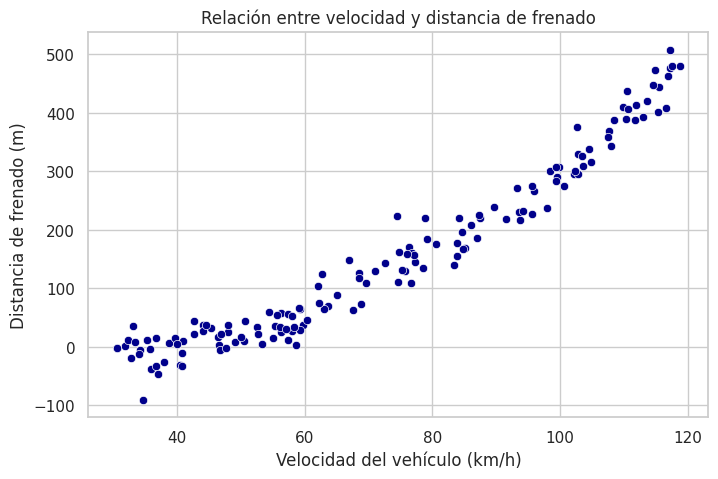

In [19]:
# Paso 2: Visualización de la relación entre velocidad y distancia

import matplotlib.pyplot as plt
import seaborn as sns

# Estilo
sns.set(style="whitegrid")

# Gráfico de dispersión
plt.figure(figsize=(8, 5))
sns.scatterplot(x='velocidad', y='distancia', data=df, color='darkblue')
plt.title('Relación entre velocidad y distancia de frenado')
plt.xlabel('Velocidad del vehículo (km/h)')
plt.ylabel('Distancia de frenado (m)')
plt.show()




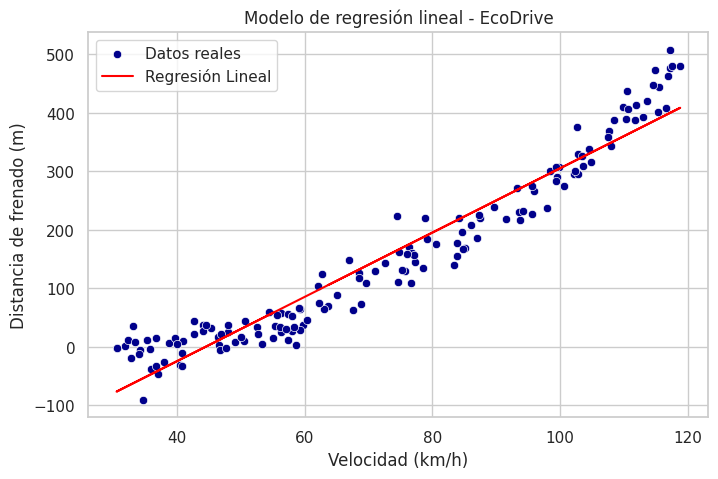

In [20]:
# Paso 3: Ajuste de modelo de regresión lineal como base comparativa
from sklearn.linear_model import LinearRegression
import numpy as np

# Definir X y y
X = df[['velocidad']]
y = df['distancia']

# Ajustar modelo lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X, y)

# Predicción
df['pred_lineal'] = modelo_lineal.predict(X)

# Visualización
plt.figure(figsize=(8, 5))
sns.scatterplot(x='velocidad', y='distancia', data=df, color='darkblue', label='Datos reales')
plt.plot(df['velocidad'], df['pred_lineal'], color='red', label='Regresión Lineal')
plt.title('Modelo de regresión lineal - EcoDrive')
plt.xlabel('Velocidad (km/h)')
plt.ylabel('Distancia de frenado (m)')
plt.legend()
plt.show()


In [26]:
# Paso 4: Comparación de modelos grado 1 y grado 2
import pandas as pd
import statsmodels.api as sm

# Cargar el dataset
df = pd.read_csv("datos_frenado.csv")

# Crear variables para el modelo polinomial grado 2
df["velocidad_2"] = df["velocidad"] ** 2

# Función para ajustar modelo de grado n
def ajustar_modelo_grado(grado):
    columnas = ["velocidad"] + [f"velocidad_{i}" for i in range(2, grado + 1)]
    X = df[columnas]
    X = sm.add_constant(X)
    y = df["distancia"]
    modelo = sm.OLS(y, X).fit()
    print(f"\nResumen del modelo de regresión polinomial grado {grado}:\n")
    print(modelo.summary())
    return modelo

# Ajustamos y mostramos resultados
modelo_grado_1 = ajustar_modelo_grado(1)
modelo_grado_2 = ajustar_modelo_grado(2)

# Crear tabla comparativa
resultados = pd.DataFrame({
    "Grado del modelo": ["1", "2"],
    "R²": [modelo_grado_1.rsquared, modelo_grado_2.rsquared],
    "R² ajustado": [modelo_grado_1.rsquared_adj, modelo_grado_2.rsquared_adj],
    "MAE": [
        (abs(modelo_grado_1.resid).mean()),
        (abs(modelo_grado_2.resid).mean())
    ],
    "MSE": [
        (modelo_grado_1.resid ** 2).mean(),
        (modelo_grado_2.resid ** 2).mean()
    ]
})

display(resultados)





Resumen del modelo de regresión polinomial grado 1:

                            OLS Regression Results                            
Dep. Variable:              distancia   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     1968.
Date:                Fri, 01 Aug 2025   Prob (F-statistic):           2.23e-87
Time:                        22:46:21   Log-Likelihood:                -766.47
No. Observations:                 150   AIC:                             1537.
Df Residuals:                     148   BIC:                             1543.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

,Grado del modelo,R²,R² ajustado,MAE,MSE
0,1,0.930043,0.929570,32.78326,1606.272224
1,2,0.971313,0.970923,20.47028,658.672302


In [28]:
# Paso 5: Comparación de modelos grado 1 y al grado 5

import pandas as pd
import statsmodels.api as sm

# Cargar el dataset
df = pd.read_csv("datos_frenado.csv")

# Generar columnas necesarias hasta grado 5
for i in range(2, 6):
    df[f"velocidad_{i}"] = df["velocidad"] ** i

# Función para ajustar modelo polinomial de grado n
def ajustar_modelo_grado(grado):
    columnas = ["velocidad"] + [f"velocidad_{i}" for i in range(2, grado + 1)]
    X = df[columnas]
    X = sm.add_constant(X)
    y = df["distancia"]
    modelo = sm.OLS(y, X).fit()
    print(f"\nResumen del modelo de regresión polinomial grado {grado}:\n")
    print(modelo.summary())
    return modelo

# Ajustar modelos de grado 1, 2, 3 y 5
modelo_grado_1 = ajustar_modelo_grado(1)
modelo_grado_2 = ajustar_modelo_grado(2)
modelo_grado_3 = ajustar_modelo_grado(3)
modelo_grado_5 = ajustar_modelo_grado(5)


# Crear tabla comparativa con los modelos de grado 1, 2, 3 y 5
resultados = pd.DataFrame({
    "Grado del modelo": ["1", "2", "3", "5"],
    "R²": [
        modelo_grado_1.rsquared,
        modelo_grado_2.rsquared,
        modelo_grado_3.rsquared,
        modelo_grado_5.rsquared
    ],
    "R² ajustado": [
        modelo_grado_1.rsquared_adj,
        modelo_grado_2.rsquared_adj,
        modelo_grado_3.rsquared_adj,
        modelo_grado_5.rsquared_adj
    ],
    "MAE": [
        abs(modelo_grado_1.resid).mean(),
        abs(modelo_grado_2.resid).mean(),
        abs(modelo_grado_3.resid).mean(),
        abs(modelo_grado_5.resid).mean()
    ],
    "MSE": [
        (modelo_grado_1.resid ** 2).mean(),
        (modelo_grado_2.resid ** 2).mean(),
        (modelo_grado_3.resid ** 2).mean(),
        (modelo_grado_5.resid ** 2).mean()
    ]
})

display(resultados)



Resumen del modelo de regresión polinomial grado 1:

                            OLS Regression Results                            
Dep. Variable:              distancia   R-squared:                       0.930
Model:                            OLS   Adj. R-squared:                  0.930
Method:                 Least Squares   F-statistic:                     1968.
Date:                Fri, 01 Aug 2025   Prob (F-statistic):           2.23e-87
Time:                        23:00:21   Log-Likelihood:                -766.47
No. Observations:                 150   AIC:                             1537.
Df Residuals:                     148   BIC:                             1543.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

,Grado del modelo,R²,R² ajustado,MAE,MSE
0,1,0.930043,0.929570,32.783260,1606.272224
1,2,0.971313,0.970923,20.470280,658.672302
2,3,0.971406,0.970818,20.400358,656.546474
3,5,0.972847,0.971905,19.763876,623.448623


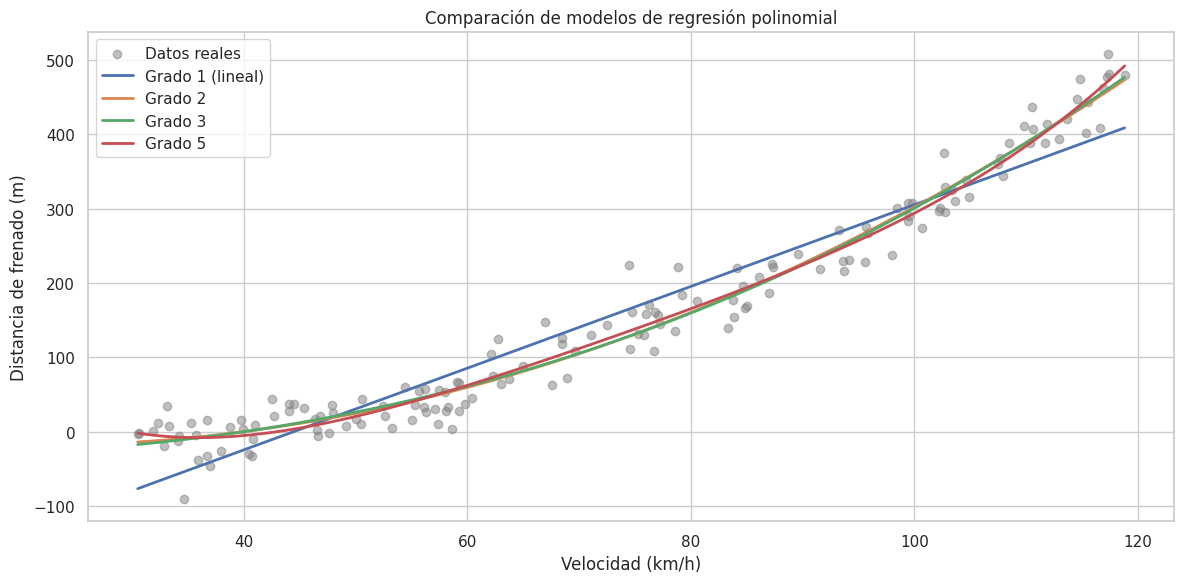

In [29]:
# Paso 5: Visualización del modelo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Cargar datos
df = pd.read_csv("datos_frenado.csv")

# Crear columnas polinomiales
df["velocidad_2"] = df["velocidad"] ** 2
df["velocidad_3"] = df["velocidad"] ** 3
df["velocidad_4"] = df["velocidad"] ** 4
df["velocidad_5"] = df["velocidad"] ** 5

# Función para entrenar modelo
def entrenar_modelo(grado):
    columnas = ["velocidad"] + [f"velocidad_{i}" for i in range(2, grado + 1)]
    X = df[columnas]
    X = sm.add_constant(X)
    y = df["distancia"]
    modelo = sm.OLS(y, X).fit()
    return modelo

# Entrenar modelos
modelo_1 = entrenar_modelo(1)
modelo_2 = entrenar_modelo(2)
modelo_3 = entrenar_modelo(3)
modelo_5 = entrenar_modelo(5)

# Generar valores para graficar
x_vals = np.linspace(df["velocidad"].min(), df["velocidad"].max(), 300)
df_plot = pd.DataFrame({"velocidad": x_vals})
df_plot["velocidad_2"] = x_vals ** 2
df_plot["velocidad_3"] = x_vals ** 3
df_plot["velocidad_4"] = x_vals ** 4
df_plot["velocidad_5"] = x_vals ** 5

# Predecir
def predecir(modelo, grado):
    columnas = ["velocidad"] + [f"velocidad_{i}" for i in range(2, grado + 1)]
    X = df_plot[columnas]
    X = sm.add_constant(X)
    return modelo.predict(X)

y_pred_1 = predecir(modelo_1, 1)
y_pred_2 = predecir(modelo_2, 2)
y_pred_3 = predecir(modelo_3, 3)
y_pred_5 = predecir(modelo_5, 5)

# Graficar
plt.figure(figsize=(12, 6))
plt.scatter(df["velocidad"], df["distancia"], color="gray", label="Datos reales", alpha=0.5)
plt.plot(x_vals, y_pred_1, label="Grado 1 (lineal)", linewidth=2)
plt.plot(x_vals, y_pred_2, label="Grado 2", linewidth=2)
plt.plot(x_vals, y_pred_3, label="Grado 3", linewidth=2)
plt.plot(x_vals, y_pred_5, label="Grado 5", linewidth=2)
plt.xlabel("Velocidad (km/h)")
plt.ylabel("Distancia de frenado (m)")
plt.title("Comparación de modelos de regresión polinomial")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 4.2 Regularización: Ridge y Lasso

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Simular datos
np.random.seed(42)
X = np.random.randn(100, 10)
true_coef = np.array([5, -3] + [0]*8)  # Solo dos variables relevantes
y = X @ true_coef + np.random.normal(0, 1, 100)

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelos
lr = LinearRegression().fit(X_train, y_train)
lasso = Lasso(alpha=0.5).fit(X_train, y_train)
ridge = Ridge(alpha=0.5).fit(X_train, y_train)

# Evaluación
modelos = {
    "Lineal": lr,
    "Lasso": lasso,
    "Ridge": ridge
}

resultados = []
for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    resultados.append({
        "Modelo": nombre,
        "R²": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "MSE": mean_squared_error(y_test, y_pred)
    })

df_resultados = pd.DataFrame(resultados)

# Mostrar coeficientes
coeficientes = pd.DataFrame({
    "Variable": [f"X{i+1}" for i in range(10)],
    "Lineal": lr.coef_,
    "Lasso": lasso.coef_,
    "Ridge": ridge.coef_
})

# Graficar
coeficientes.set_index("Variable").plot(kind="bar", figsize=(10,5))
plt.title("Comparación de coeficientes: Lineal vs Lasso vs Ridge")
plt.ylabel("Valor del coeficiente")
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar tabla de resultados
print(df_resultados)


## 4.3 Aplicación de la regularización L1 (Lasso) y L2 (Ridge)

In [31]:
# Paso 1: Carga del dataset y revisión general

import pandas as pd

# Cargar el archivo CSV generado previamente
df = pd.read_csv("datos_frenado.csv")

# Verificar tipos de datos y valores nulos
print("\nInformación general del DataFrame:")
print(df.info())



Información general del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   velocidad       150 non-null    float64
 1   distancia       150 non-null    float64
 2   clima           150 non-null    object 
 3   frenos_abs      150 non-null    object 
 4   carga_vehiculo  150 non-null    float64
 5   ruido_sensor    150 non-null    float64
dtypes: float64(4), object(2)
memory usage: 7.2+ KB
None


In [34]:
# Paso 2: Preparar los datos para la regresión con regularización (Ridge y Lasso)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Codificación de variables categóricas
df_encoded = pd.get_dummies(df, columns=["clima", "frenos_abs"], drop_first=True)
for col in df_encoded.select_dtypes(include='bool').columns:
    df_encoded[col] = df_encoded[col].astype(int)


# 2. Separar variables independientes y dependiente
X = df_encoded.drop(columns="distancia")
y = df_encoded["distancia"]

# 3. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [37]:
# Paso 3: Entrenamiento de modelos de regresión

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Entrenar modelos
modelo_lineal = LinearRegression()
modelo_ridge = Ridge(alpha=1.0)
modelo_lasso = Lasso(alpha=0.1)

# Ajustar a los datos de entrenamiento
modelo_lineal.fit(X_train_scaled, y_train)
modelo_ridge.fit(X_train_scaled, y_train)
modelo_lasso.fit(X_train_scaled, y_train)

# Predecir sobre datos de prueba
y_pred_lineal = modelo_lineal.predict(X_test_scaled)
y_pred_ridge = modelo_ridge.predict(X_test_scaled)
y_pred_lasso = modelo_lasso.predict(X_test_scaled)

# Evaluación
def evaluar_modelo(nombre, y_test, y_pred):
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Resultados para {nombre}:")
    print(f"R²: {r2:.4f}")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print("-" * 40)

# Mostrar resultados
evaluar_modelo("Regresión Lineal", y_test, y_pred_lineal)
evaluar_modelo("Ridge (L2)", y_test, y_pred_ridge)
evaluar_modelo("Lasso (L1)", y_test, y_pred_lasso)


Resultados para Regresión Lineal:
R²: 0.9400
MAE: 28.84
MSE: 1452.54
----------------------------------------
Resultados para Ridge (L2):
R²: 0.9406
MAE: 28.71
MSE: 1437.48
----------------------------------------
Resultados para Lasso (L1):
R²: 0.9403
MAE: 28.80
MSE: 1444.57
----------------------------------------


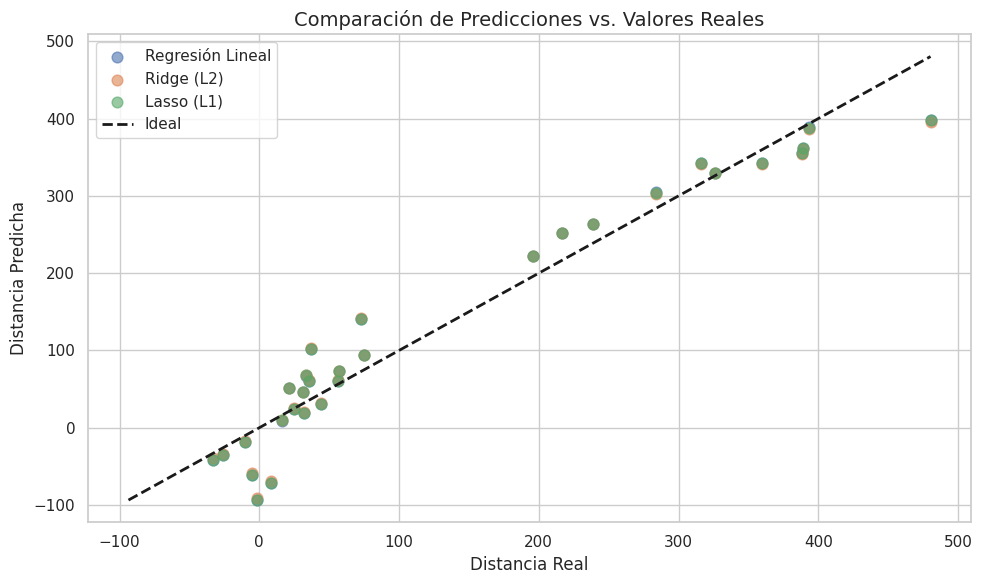

In [38]:
# Paso 4. Visualización de predicciones vs. valores reales
import matplotlib.pyplot as plt

# Tamaño de la figura
plt.figure(figsize=(10, 6))

# Gráficas de dispersión
plt.scatter(y_test, y_pred_lineal, label="Regresión Lineal", alpha=0.6, s=60)
plt.scatter(y_test, y_pred_ridge, label="Ridge (L2)", alpha=0.6, s=60)
plt.scatter(y_test, y_pred_lasso, label="Lasso (L1)", alpha=0.6, s=60)

# Línea identidad (predicción perfecta)
min_val = min(y_test.min(), y_pred_lineal.min(), y_pred_ridge.min(), y_pred_lasso.min())
max_val = max(y_test.max(), y_pred_lineal.max(), y_pred_ridge.max(), y_pred_lasso.max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label="Ideal")

# Títulos y etiquetas
plt.title("Comparación de Predicciones vs. Valores Reales", fontsize=14)
plt.xlabel("Distancia Real")
plt.ylabel("Distancia Predicha")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [40]:
# Paso 5. Visualización de variables activas en los modelos
import numpy as np
import pandas as pd

# Obtener coeficientes de cada modelo
coef_lineal = modelo_lineal.coef_
coef_ridge = modelo_ridge.coef_
coef_lasso = modelo_lasso.coef_

# Contar cuántos coeficientes son diferentes de cero (sin contar la constante)
num_coef_lineal = np.sum(coef_lineal != 0)
num_coef_ridge = np.sum(coef_ridge != 0)
num_coef_lasso = np.sum(coef_lasso != 0)

# Crear tabla
tabla_coeficientes = pd.DataFrame({
    "Modelo": ["Regresión lineal", "Ridge (L2)", "Lasso (L1)"],
    "Variables activas (≠ 0)": [num_coef_lineal, num_coef_ridge, num_coef_lasso]
})

# Mostrar tabla
display(tabla_coeficientes)


,Modelo,Variables activas (≠ 0)
0,Regresión lineal,6
1,Ridge (L2),6
2,Lasso (L1),5


# Tema 5. Aplicación en Python de los árboles de decisión y bosques aleatorios

## 5.1. Árboles de clasificación y regresión

### Caso 1: Clasificación con el dataset penguins

In [4]:
# Paso 1: Cargar y preparar los datos

import seaborn as sns
import pandas as pd

# Cargar el dataset y eliminar valores faltantes
df = sns.load_dataset("penguins").dropna()

# Seleccionar variables numéricas y la etiqueta
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
X = df[features]
y = df['species']


In [5]:
# Paso 2: Codificar las etiquetas y dividir los datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Codificación de etiquetas
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)


In [6]:
# Paso 3: Entrenar el modelo de clasificación
from sklearn.tree import DecisionTreeClassifier

# Entrenar árbol de clasificación
clf = DecisionTreeClassifier(max_depth=4, random_state=42)
clf.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=4, random_state=42)

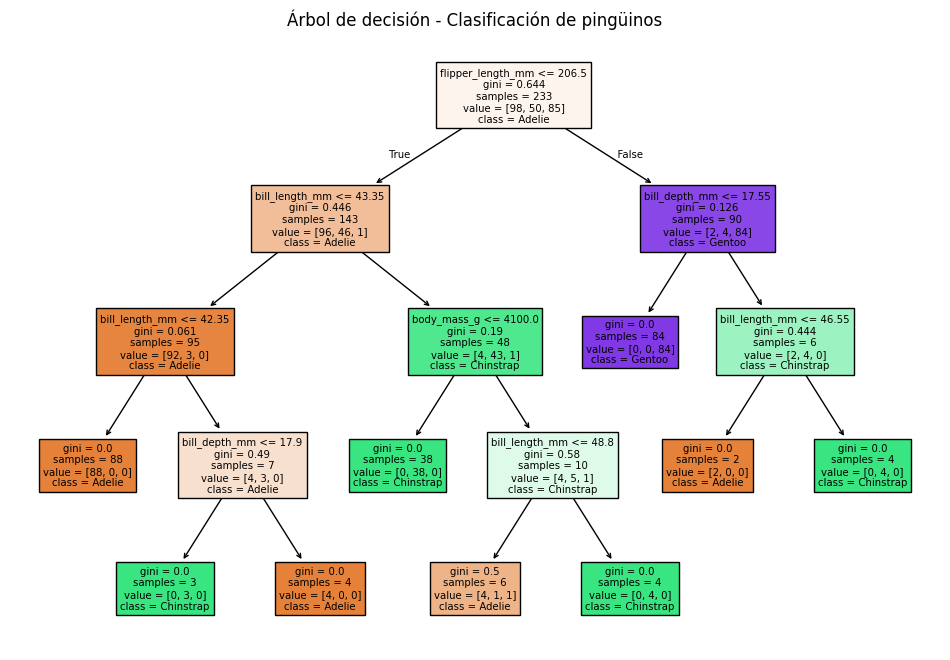

In [7]:
# Paso 4: Visualizar el árbol

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf, feature_names=features, class_names=le.classes_, filled=True)
plt.title("Árbol de decisión - Clasificación de pingüinos")
plt.show()


### Caso 2: Regresión con el dataset diabetes

In [8]:
# Paso 1: Cargar los datos

from sklearn.datasets import load_diabetes

data = load_diabetes(as_frame=True)
df = data.frame
X = df.drop('target', axis=1)
y = df['target']


In [11]:
# Paso 2: Dividir datos y entrenar modelo (depth 2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor(max_depth=2, random_state=42)
reg.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=2, random_state=42)

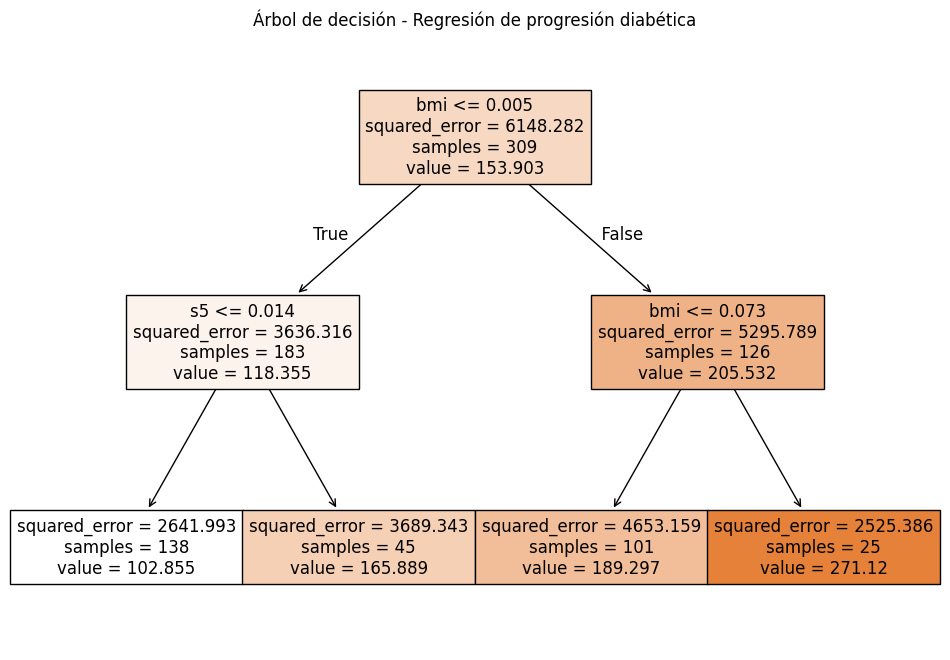

In [12]:
# Paso 3: Visualizar árbol de regresión
plt.figure(figsize=(12,8))
plot_tree(reg, feature_names=X.columns, filled=True)
plt.title("Árbol de decisión - Regresión de progresión diabética")
plt.show()


In [15]:
# Paso 2.1: Dividir datos y entrenar modelo (depth 4)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

from sklearn.tree import DecisionTreeRegressor

reg = DecisionTreeRegressor(max_depth=4, random_state=42)
reg.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=4, random_state=42)

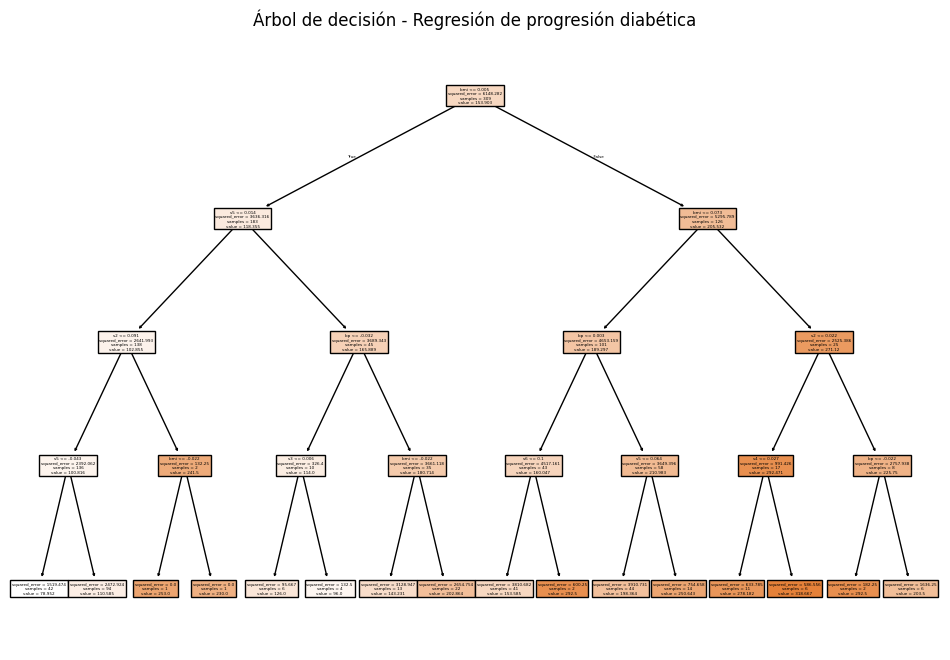

In [16]:
# Paso 3.1: Visualizar árbol de regresión (4)
plt.figure(figsize=(12,8))
plot_tree(reg, feature_names=X.columns, filled=True)
plt.title("Árbol de decisión - Regresión de progresión diabética")
plt.show()

## 5.2. La impureza de Gini

In [1]:
# Paso 1: Cargar los datos y preparar conjuntos
from sklearn.datasets import load_iris
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar dataset
iris = load_iris(as_frame=True)
df = iris.frame

X = df.drop(columns='target')
y = df['target']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)


In [2]:
# Paso 2: Entrenar el modelo con criterio Gini
from sklearn.tree import DecisionTreeClassifier

# Entrenar árbol con criterio Gini
clf_gini = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=0)
clf_gini.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=3, random_state=0)

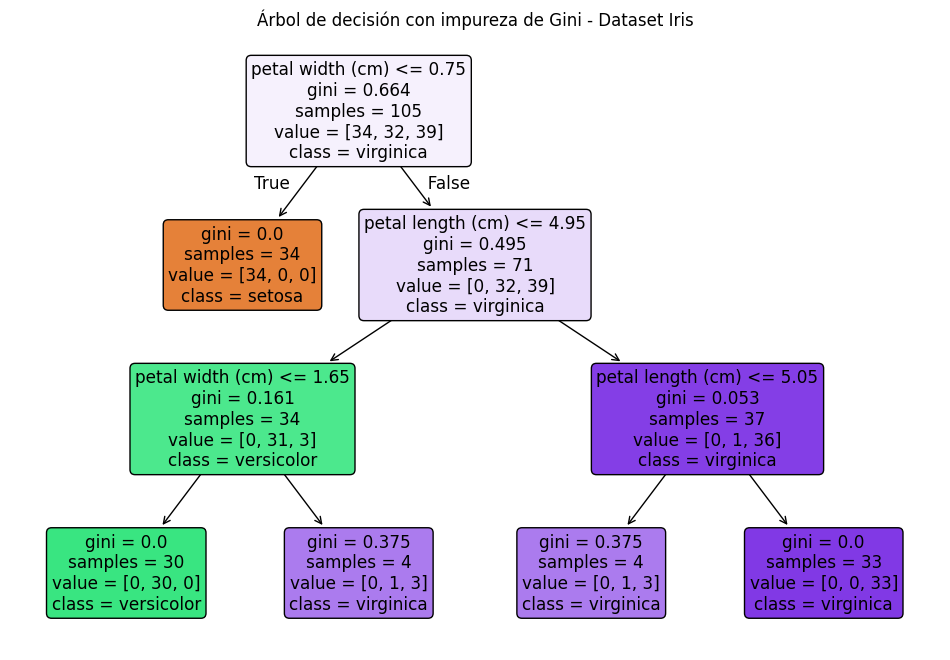

In [3]:
# Paso 3: Visualizar el árbol y su impureza
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(clf_gini, feature_names=X.columns,
          class_names=iris.target_names,
          filled=True, rounded=True)
plt.title("Árbol de decisión con impureza de Gini - Dataset Iris")
plt.show()


## 5.3. Random Forest


In [11]:
# Paso 1: Cargar y preparar el dataset

import seaborn as sns
import pandas as pd

# Cargar datos y seleccionar variables de interés
df = sns.load_dataset('titanic')[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']]
df = df.dropna()  # Eliminar filas con valores nulos

# Codificar variables categóricas
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)


In [12]:
# Paso 2: Separar variables predictoras y etiqueta
X = df.drop(columns='survived')
y = df['survived']


In [13]:
# Paso 3: Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [14]:
# Paso 4: Entrenar el modelo de Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=5, random_state=42)

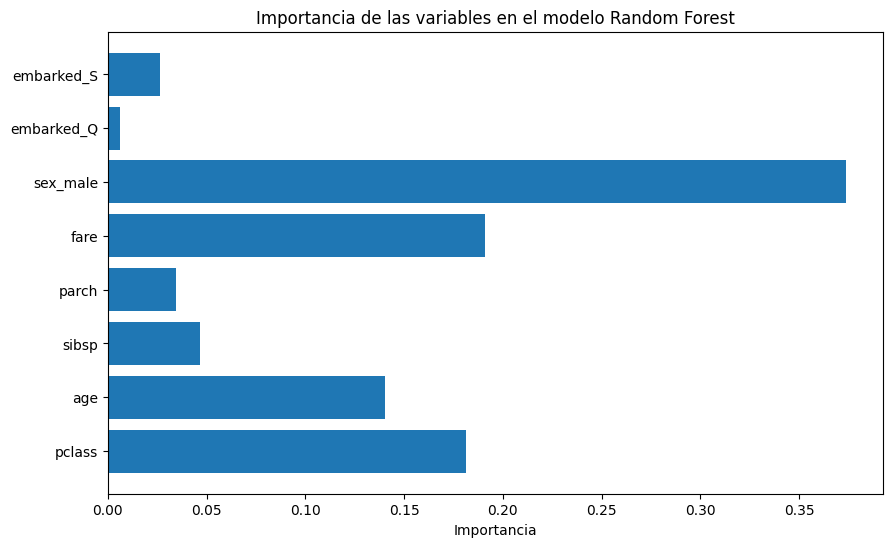

In [15]:
# Paso 5: Importancia de variables
import matplotlib.pyplot as plt
import numpy as np

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.xlabel("Importancia")
plt.title("Importancia de las variables en el modelo Random Forest")
plt.show()


In [16]:
#Paso 6. Evaluar el desempeño

from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test)
print("Precisión:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))


Precisión: 0.780373831775701

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.77      0.87      0.82       122
           1       0.79      0.66      0.72        92

    accuracy                           0.78       214
   macro avg       0.78      0.77      0.77       214
weighted avg       0.78      0.78      0.78       214



## 5.4. Métricas de evaluación en árboles de decisión y bosques aleatorios

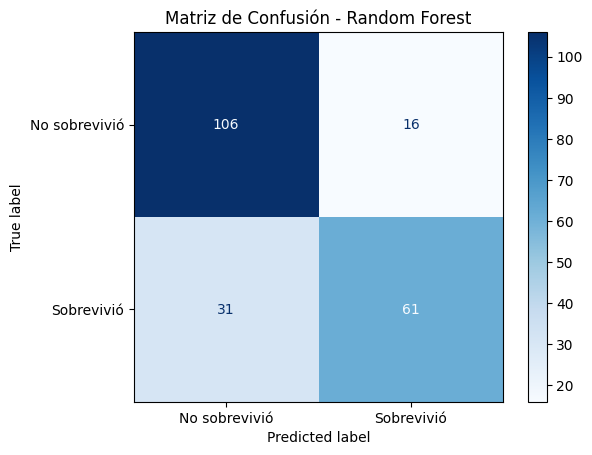

In [17]:
#Paso 1: Mostrar la matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
disp.plot(cmap='Blues')
plt.title("Matriz de Confusión - Random Forest")
plt.show()


In [18]:
# Paso 2: Reporte de métricas
from sklearn.metrics import classification_report

print("Reporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["No sobrevivió", "Sobrevivió"]))


Reporte de clasificación:

               precision    recall  f1-score   support

No sobrevivió       0.77      0.87      0.82       122
   Sobrevivió       0.79      0.66      0.72        92

     accuracy                           0.78       214
    macro avg       0.78      0.77      0.77       214
 weighted avg       0.78      0.78      0.78       214



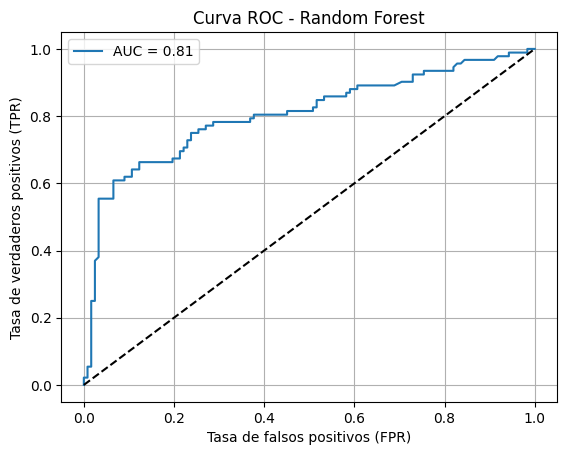

In [19]:
# Paso 3: Curva ROC y AUC
from sklearn.metrics import roc_curve, roc_auc_score

y_proba = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("Tasa de falsos positivos (FPR)")
plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC - Random Forest")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
# Ejemplo práctico con RandomForestRegressor (dataset diabetes)

from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Cargar datos
data = load_diabetes(as_frame=True)
df = data.frame
X = df.drop(columns='target')
y = df['target']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Entrenar modelo
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
rf_reg.fit(X_train, y_train)

# Predicciones
y_pred = rf_reg.predict(X_test)

# Evaluación
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


MAE: 42.18
RMSE: 52.62
R²: 0.49


# Tema 6. Aplicación en Python del modelo K vecinos más cercanos

## 6.1. Algoritmo KNN


In [21]:
#Paso 1: Importar librerías necesarias
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
# Paso 2: Cargar y explorar el dataset
# Cargar el dataset Iris
iris = load_iris()
X = iris.data
y = iris.target

# Crear un DataFrame para exploración
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df['species'] = df['target'].map(dict(zip(range(3), iris.target_names)))
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [23]:
# Paso 3: Dividir los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [24]:
# Paso 4: Escalar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [25]:
# Paso 5: Entrenar el modelo KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier()

In [28]:
# Paso 6: Predecir con el modelo
y_pred = knn.predict(X_test_scaled)
print("Predicciones:", y_pred)


Predicciones: [0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 1 0 2 1 1 2 1 1 0 2 0]
[np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('versicolor'), np.str_('setosa'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('virginica'), np.str_('virginica'), np.str_('virginica'), np.str_('versicolor'), np.str_('setosa'), np.str_('setosa'), np.str_('setosa'), np.str_('versicolor'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('virginica'), np.str_('versicolor'), np.str_('versicolor'), np.str_('setosa'), np.str_('virginica'), np.str_('setosa')]


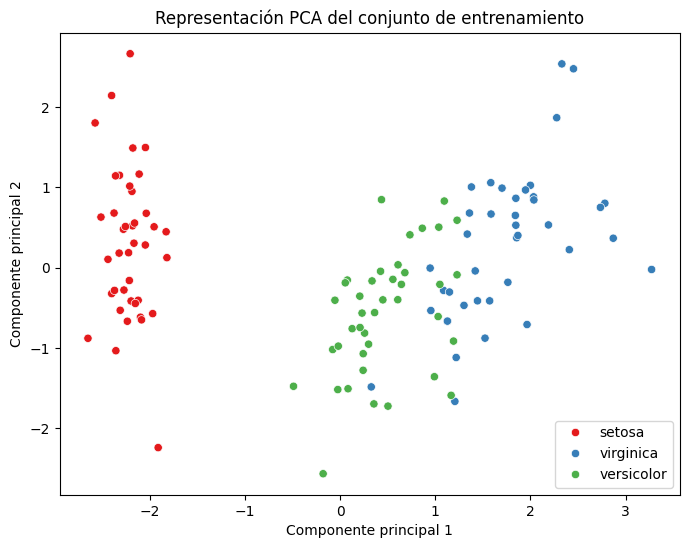

In [27]:
# Paso 7: Visualizar con reducción de dimensiones (opcional)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X_train_scaled)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_reduced[:, 0], y=X_reduced[:, 1], hue=iris.target_names[y_train], palette="Set1")
plt.title("Representación PCA del conjunto de entrenamiento")
plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.show()


## 6.2. Métricas de evaluación del modelo K vecinos más cercanos

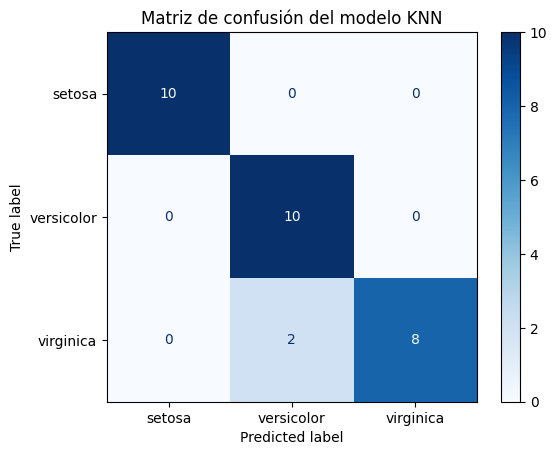

In [29]:
# Paso 1: Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Generar matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Visualizarla
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=iris.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de confusión del modelo KNN")
plt.show()


In [30]:
# Paso 2: Cálculo de precisión general (accuracy)
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión del modelo KNN: {accuracy:.2f}")


Precisión del modelo KNN: 0.93


In [31]:
# Paso 3: Métricas por clase (Precision, Recall, F1-score)
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



In [32]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Cargar el dataset
cancer = load_breast_cancer()

# Convertirlo en DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['target_label'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Ver las primeras filas
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


# 7. Aplicación en Python de las máquinas de soporte vectorial

## 7.1. Máquinas de soporte vectorial lineales

In [5]:
# Paso 1: Cargar y explorar el dataset
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Cargar datos
cancer = load_breast_cancer()

# Convertir a DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target
df['target_label'] = df['target'].map({0: 'malignant', 1: 'benign'})

# Visualizar primeras filas
df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [6]:
# Paso 2: Seleccionar dos variables para visualización bidimensional
X = df[['mean radius', 'mean texture']].values
y = df['target'].values


In [7]:
# Paso 3: División en entrenamiento y prueba
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)


In [8]:
# Paso 4: Escalar las variables
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
# Paso 5: Entrenar el modelo SVM lineal
from sklearn.svm import SVC

# Crear y entrenar modelo SVM con kernel lineal
svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train_scaled, y_train)


SVC(kernel='linear')

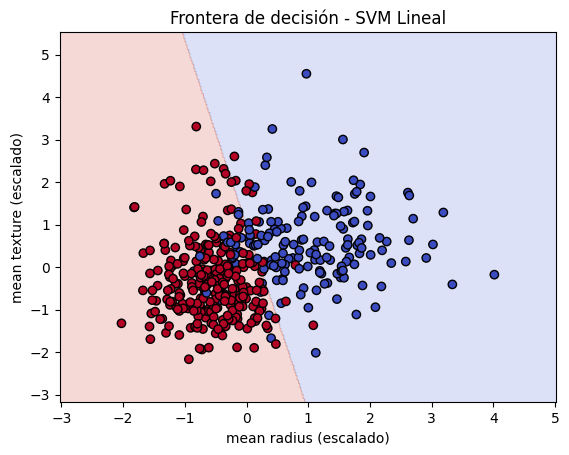

In [10]:
# Paso 6: Visualización de la frontera de decisión
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.2, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.xlabel('mean radius (escalado)')
    plt.ylabel('mean texture (escalado)')
    plt.title('Frontera de decisión - SVM Lineal')
    plt.show()

plot_decision_boundary(svm_linear, X_train_scaled, y_train)


In [11]:
# Paso 7: Predicción en datos de prueba
y_pred = svm_linear.predict(X_test_scaled)
print("Predicciones:", y_pred)


Predicciones: [0 1 1 0 0 1 1 0 0 0 1 1 1 0 0 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 1 0 1 1
 1 1 0 1 1 1 0 1 1 1 1 0 0 1 0 1 1 1 1 1 0 0 1 1 1 1 1 0 0 0 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 1 1 0 0 1 0 1 0 1
 0 1 1]


In [15]:
# 7.1 Conteo de clases predichas:
import numpy as np
unique, counts = np.unique(y_pred, return_counts=True)
dict(zip(unique, counts))



{np.int64(0): np.int64(41), np.int64(1): np.int64(73)}

In [16]:
# 7.2 Visualización de tabla de valores
import pandas as pd
pd.DataFrame({'Real': y_test, 'Predicho': y_pred})

,Real,Predicho
0,0,0
1,1,1
2,0,1
3,1,0
4,0,0
...,...,...
109,0,0
110,1,1
111,0,0
112,1,1


In [12]:
# Paso 8: Exploración rápida del desempeño
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión en datos de prueba: {accuracy:.2f}")


Precisión en datos de prueba: 0.87


## 7.2. Máquinas de soporte vectorial no lineales (Kernel RBF)

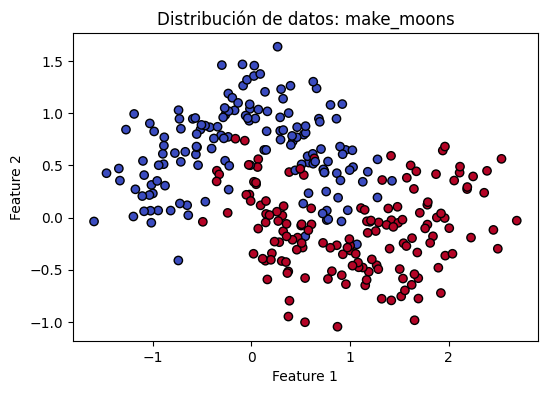

In [23]:
# Paso 1: Generar un dataset no lineal (make_moons)
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

# Generar datos
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

# Visualización inicial
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolor='k')
plt.title("Distribución de datos: make_moons")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


In [24]:
# Paso 2: División y escalado de los datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separar datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# Escalamiento
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
# Paso 3: Entrenar una SVM con kernel lineal
from sklearn.svm import SVC

svm_linear = SVC(kernel='linear', C=1.0)
svm_linear.fit(X_train_scaled, y_train)


SVC(kernel='linear')

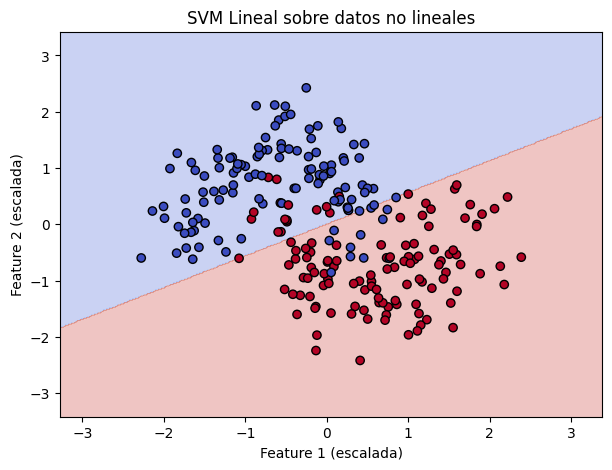

In [29]:
# Paso 4: Visualizar frontera lineal
import numpy as np

def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title(title)
    plt.xlabel("Feature 1 (escalada)")
    plt.ylabel("Feature 2 (escalada)")
    plt.show()

plot_decision_boundary(svm_linear, X_train_scaled, y_train,
                       "SVM Lineal sobre datos no lineales")


In [30]:
# Paso 5: Evaluación del modelo lineal
from sklearn.metrics import accuracy_score

y_pred_linear = svm_linear.predict(X_test_scaled)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Precisión del modelo SVM lineal: {accuracy_linear:.2f}")


Precisión del modelo SVM lineal: 0.80


In [31]:
# Paso 6: Entrenar una SVM con kernel RBF
from sklearn.svm import SVC

# Crear modelo con kernel RBF (no lineal)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')  # gamma controla la forma de la frontera
svm_rbf.fit(X_train_scaled, y_train)


SVC()

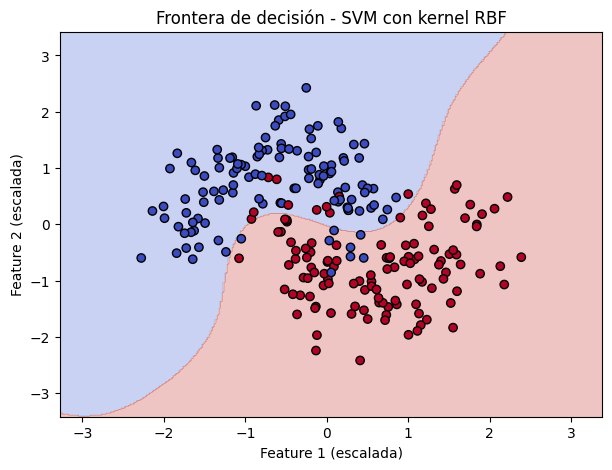

In [32]:
# Paso 7: Visualizar la frontera de decisión (RBF)
import numpy as np

def plot_decision_boundary(model, X, y):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
    plt.title("Frontera de decisión - SVM con kernel RBF")
    plt.xlabel("Feature 1 (escalada)")
    plt.ylabel("Feature 2 (escalada)")
    plt.show()

plot_decision_boundary(svm_rbf, X_train_scaled, y_train)


In [35]:
# Paso 8: Evaluación rápida del modelo
from sklearn.metrics import accuracy_score

y_pred_rbf = svm_rbf.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Precisión en datos de prueba (SVM no lineal): {accuracy:.2f}")


Precisión en datos de prueba (SVM no lineal): 0.85


## 7.3 Métricas de evaluación en modelos de máquinas de soporte vectorial lineal y no lineal

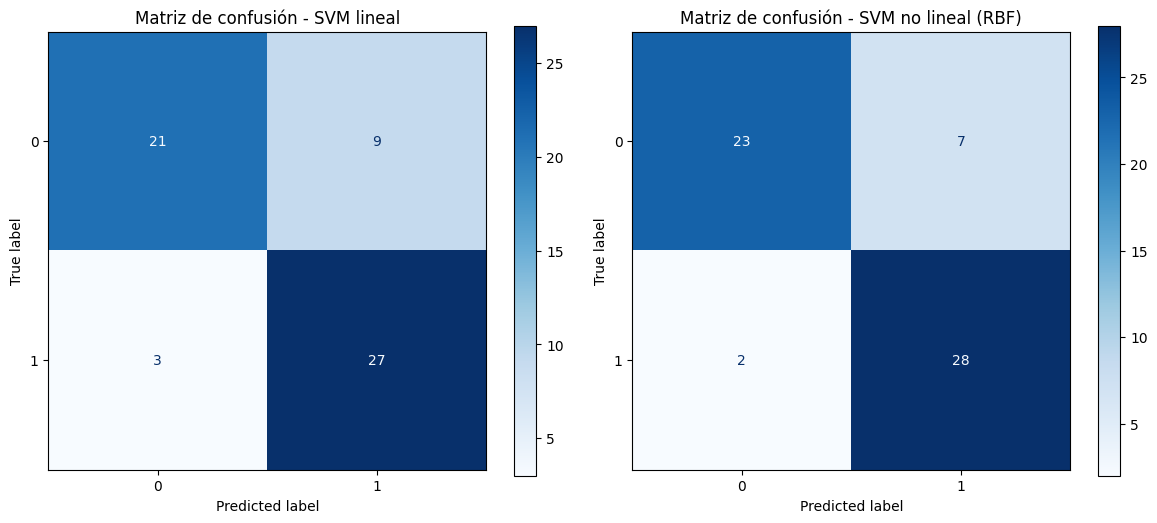

In [37]:
# Paso 1: Comparar visualmente las predicciones con la matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Crear una figura con dos subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matriz para SVM lineal
cm_linear = confusion_matrix(y_test, y_pred_linear)
disp_linear = ConfusionMatrixDisplay(confusion_matrix=cm_linear)
disp_linear.plot(cmap='Blues', ax=ax1)
ax1.set_title("Matriz de confusión - SVM lineal")

# Matriz para SVM con kernel RBF
cm_rbf = confusion_matrix(y_test, y_pred_rbf)
disp_rbf = ConfusionMatrixDisplay(confusion_matrix=cm_rbf)
disp_rbf.plot(cmap='Blues', ax=ax2)
ax2.set_title("Matriz de confusión - SVM no lineal (RBF)")

# Ajustar el espacio entre subplots
plt.tight_layout()
plt.show()


In [38]:
# Paso 2: Calcular métricas por clase con classification_report
from sklearn.metrics import classification_report

print("Reporte de clasificación - SVM Lineal")
print(classification_report(y_test, y_pred_linear))

print("Reporte de clasificación - SVM No Lineal (RBF)")
print(classification_report(y_test, y_pred_rbf))


Reporte de clasificación - SVM Lineal
              precision    recall  f1-score   support

           0       0.88      0.70      0.78        30
           1       0.75      0.90      0.82        30

    accuracy                           0.80        60
   macro avg       0.81      0.80      0.80        60
weighted avg       0.81      0.80      0.80        60

Reporte de clasificación - SVM No Lineal (RBF)
              precision    recall  f1-score   support

           0       0.92      0.77      0.84        30
           1       0.80      0.93      0.86        30

    accuracy                           0.85        60
   macro avg       0.86      0.85      0.85        60
weighted avg       0.86      0.85      0.85        60



# 8. Introducción a las redes neuronales y aprendizaje profundo

## 8.2. Fundamentos de las redes neuronales de avance (monocapa)

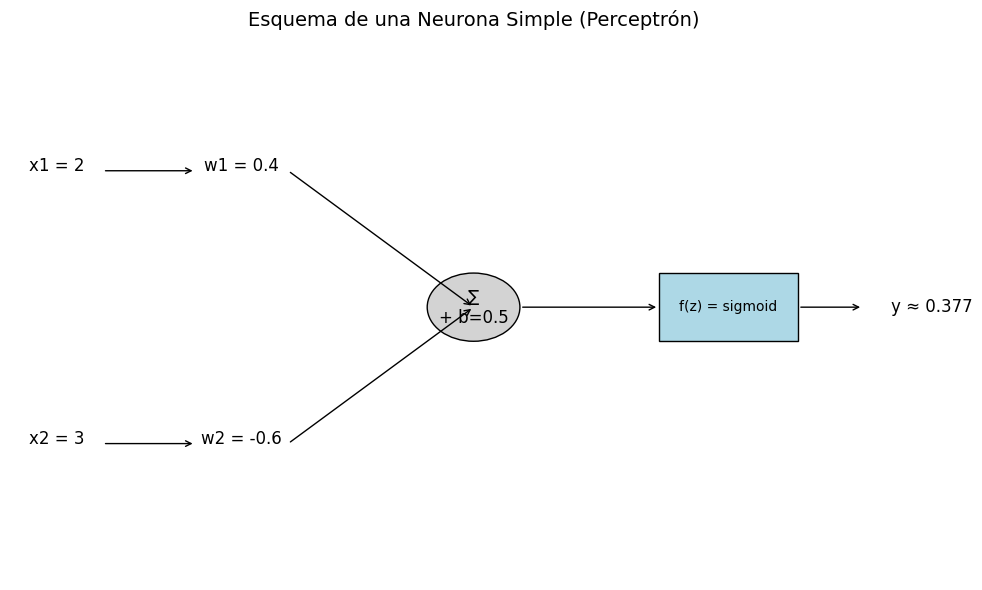

In [52]:
# Grafica para el esquema de neurona simple (Ilustración 2)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Crear figura
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis('off')

# Entradas
ax.text(0.5, 6, 'x1 = 2', fontsize=12, ha='center')
ax.text(0.5, 2, 'x2 = 3', fontsize=12, ha='center')

# Pesos
ax.text(2.5, 6, 'w1 = 0.4', fontsize=12, ha='center')
ax.text(2.5, 2, 'w2 = -0.6', fontsize=12, ha='center')

# Líneas de entrada
ax.annotate('', xy=(2, 6), xytext=(1, 6), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(2, 2), xytext=(1, 2), arrowprops=dict(arrowstyle='->'))

# Líneas hacia la suma
ax.annotate('', xy=(5, 4), xytext=(3, 6), arrowprops=dict(arrowstyle='->'))
ax.annotate('', xy=(5, 4), xytext=(3, 2), arrowprops=dict(arrowstyle='->'))

# Nodo de suma
circle_sum = patches.Circle((5, 4), radius=0.5, edgecolor='black', facecolor='lightgray')
ax.add_patch(circle_sum)
ax.text(5, 4, '∑\n+ b=0.5', fontsize=12, ha='center', va='center')

# Línea hacia función de activación
ax.annotate('', xy=(7, 4), xytext=(5.5, 4), arrowprops=dict(arrowstyle='->'))

# Función de activación
rect_activation = patches.Rectangle((7, 3.5), 1.5, 1, edgecolor='black', facecolor='lightblue')
ax.add_patch(rect_activation)
ax.text(7.75, 4, 'f(z) = sigmoid', fontsize=10, ha='center', va='center')

# Línea hacia salida
ax.annotate('', xy=(9.2, 4), xytext=(8.5, 4), arrowprops=dict(arrowstyle='->'))

# Salida
ax.text(9.5, 4, 'y ≈ 0.377', fontsize=12, ha='left', va='center')

# Título
plt.title("Esquema de una Neurona Simple (Perceptrón)", fontsize=14)
plt.tight_layout()
plt.show()


In [45]:
# PASO 1: Cargar y preparar los datos
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

# Cargar el dataset
diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = diabetes.target

# Convertir la variable objetivo a formato binario
# Umbral clínico de referencia: > 140 implica alto riesgo
y_binaria = (y > 140).astype(int)


In [46]:
# PASO 2: Escalamiento y división del conjunto de datos
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Escalar variables independientes
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_binaria, test_size=0.3, random_state=42)


In [47]:
# PASO 3: Construir y entrenar la red neuronal monocapa
from sklearn.neural_network import MLPClassifier

# Red neuronal sin capas ocultas = monocapa (perceptrón simple)
modelo = MLPClassifier(hidden_layer_sizes=(), activation='logistic', max_iter=1000, random_state=42)

# Entrenamiento del modelo
modelo.fit(X_train, y_train)


MLPClassifier(activation='logistic', hidden_layer_sizes=(), max_iter=1000,
              random_state=42)

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        72
           1       0.76      0.79      0.77        61

    accuracy                           0.79       133
   macro avg       0.79      0.79      0.79       133
weighted avg       0.79      0.79      0.79       133



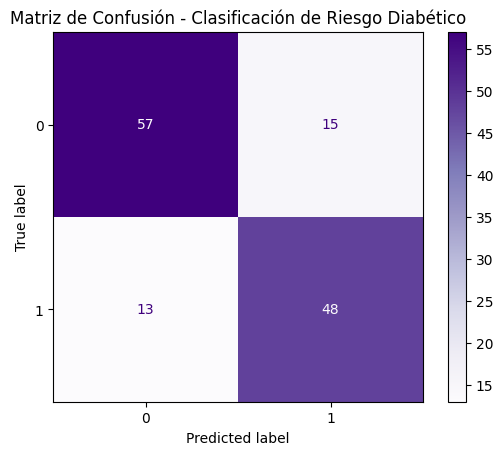

In [50]:
# PASO 4: Evaluar el desempeño del modelo
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predicciones
y_pred = modelo.predict(X_test)

# Reporte con métricas estándar
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(modelo, X_test, y_test, cmap='Purples')
plt.title("Matriz de Confusión - Clasificación de Riesgo Diabético")
plt.show()
